Import Required Libraries

In [1]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
from PIL import Image

Dataset Structure Exploration

In [2]:
dataset_path = r"C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8"

for folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, folder)
    print(folder)

data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid


Import OS Module

In [4]:
import os

Display Sample Training Images

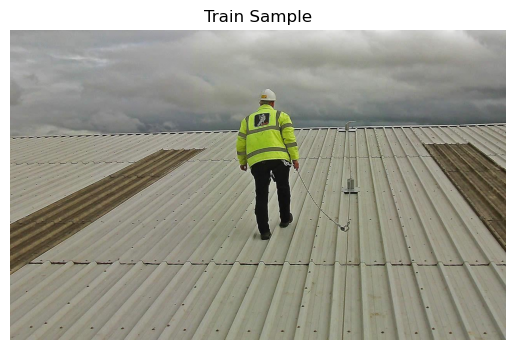

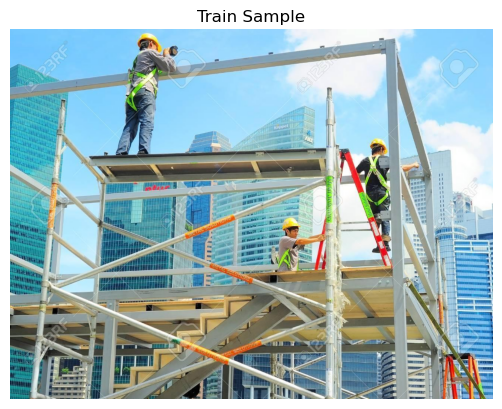

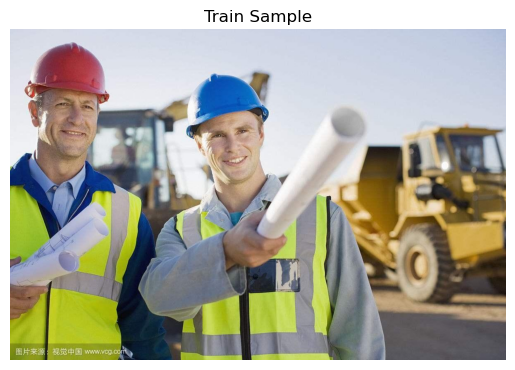

In [5]:
import random
from PIL import Image
import matplotlib.pyplot as plt

train_path = r"C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\train\images"

images = os.listdir(train_path)

for i in range(3):
    img_name = random.choice(images)
    img_path = os.path.join(train_path, img_name)

    image = Image.open(img_path)
    plt.imshow(image)
    plt.title("Train Sample")
    plt.axis("off")
    plt.show()

System Configuration Check

In [6]:
import torch, platform, psutil

print("OS:", platform.system(), platform.release())
print("RAM:", round(psutil.virtual_memory().total / 1e9, 2), "GB")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("CUDA:", torch.cuda.is_available())

OS: Windows 11
RAM: 16.83 GB
GPU: CPU only
CUDA: False


Load YOLOv8 Model

In [7]:
from ultralytics import YOLO   

model = YOLO("yolov8n.pt")

Train YOLOv8 Model

In [8]:
TRAINED_MODEL = "runs/detect/Construction_Safety_Detection/weights/best.pt"

if os.path.exists(TRAINED_MODEL):
    print("Trained model found! Loading...")
    model = YOLO(TRAINED_MODEL)
else:
    print("No trained model found. Starting training...")
    
    model = YOLO("yolov8n.pt")
    
    results = model.train(
        data=r"C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\data.yaml",
        epochs=20,
        imgsz=640,
        batch=4,
        workers=2,
        device="cpu",
        name="Construction_Safety_Detection"
    )

    print("Training Complete!")

No trained model found. Starting training...
New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.12.7 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12450H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, m

Model Validation and Performance Evaluation

In [8]:
metrics = model.val(
    data=r"C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\data.yaml"
)

print(metrics)

Ultralytics 8.4.33  Python-3.12.7 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12450H)


Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 61.149.0 MB/s, size: 105.4 KB)
val: Scanning C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\valid\labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4s/it 10.9s1.7s
                   all        119        715      0.884      0.747      0.864      0.509
                helmet        117        232      0.933      0.909       0.95       0.57
             no-helmet          6         11      0.694      0.364      0.649      0.313
               no-vest         52         90       0.88      0.789      0.835      0.443
                person        115        241      0.949      0.924      0.956      0.668
                  vest         74        141      0.963 

Final Model Training with Optimized Parameters

In [18]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=r"C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\data.yaml",
    epochs=10,        # reduce for safety
    batch=4,
    workers=2,
    device="cpu",
    name="Construction_Safety_Final"
)

Ultralytics 8.4.33  Python-3.12.7 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-12450H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Construction_Safety_Final2, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000204AC26D430>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
    

Display Prediction Results

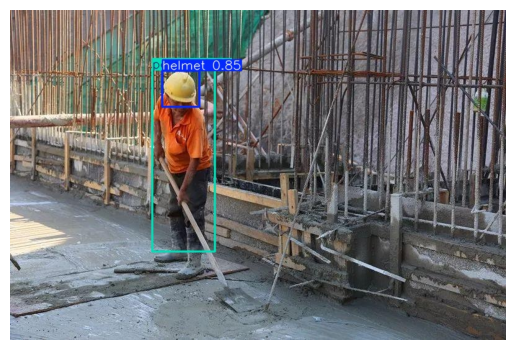

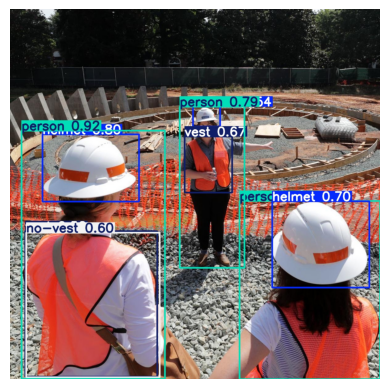

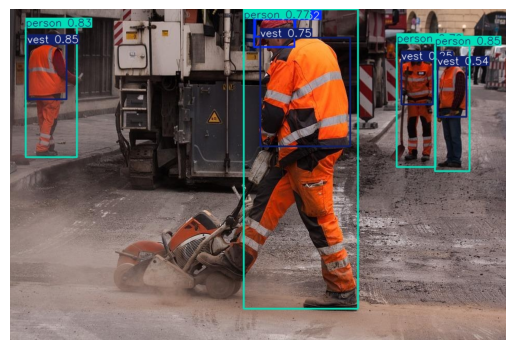

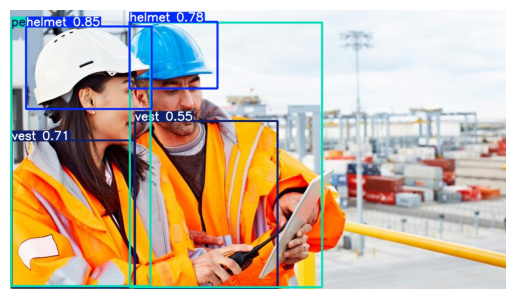

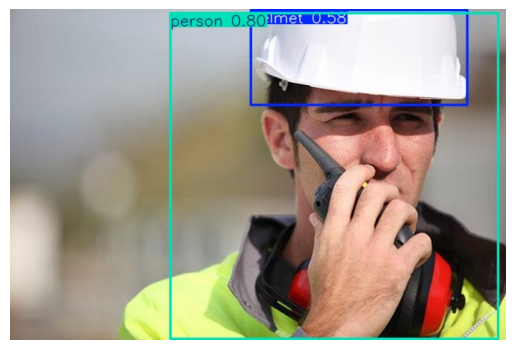

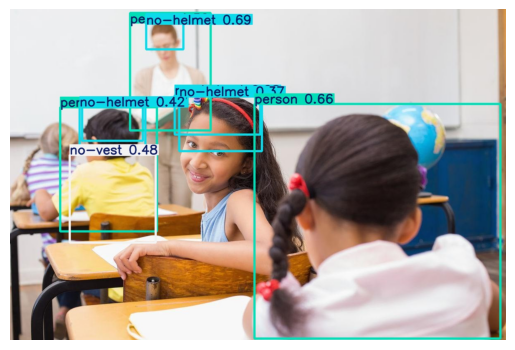

In [9]:
import glob

pred_images = glob.glob("runs/detect/predict*/**/*.jpg", recursive=True)[:6]

for img_path in pred_images:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Perform Object Detection on Test Dataset

In [21]:
model.predict(
    source=r"C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\test\images",
    save=True,
    show=True
)


image 1/90 C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\test\images\ppe_0000_jpg.rf.c102a9a7c8dec01565a8f95ff295974c.jpg: 448x640 1 helmet, 1 person, 153.5ms
image 2/90 C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\test\images\ppe_0004_jpg.rf.c3265071237f64a4f0c3e1bf3048f923.jpg: 640x640 3 helmets, 1 no-vest, 3 persons, 2 vests, 247.6ms
image 3/90 C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\test\images\ppe_0008_jpg.rf.356284e8df05dcd239cb91cf53b51c83.jpg: 448x640 2 helmets, 4 persons, 4 vests, 176.7ms
image 4/90 C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\construction safety.v2-release.yolov8\test\images\ppe_0009_jpg.rf.68866a74a26b99495ad80bc41b7a2897.jpg: 384x640 2 helmets, 2 persons, 2 vests, 224.2ms
image 5/90 C:\Users\VAISHNAVI\OneDrive\Desktop\YOLO_Object_Detection_Project\constructi

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'no-helmet', 2: 'no-vest', 3: 'person', 4: 'vest'}
 obb: None
 orig_img: array([[[ 62,  94, 137],
         [140, 165, 199],
         [120, 127, 147],
         ...,
         [163, 148, 162],
         [121, 102, 111],
         [ 72,  49,  57]],
 
        [[ 57,  89, 132],
         [137, 162, 196],
         [120, 127, 146],
         ...,
         [155, 140, 154],
         [112,  93, 102],
         [ 76,  53,  61]],
 
        [[ 51,  81, 122],
         [134, 156, 191],
         [122, 129, 148],
         ...,
         [125, 110, 124],
         [ 88,  69,  78],
         [ 76,  54,  59]],
 
        ...,
 
        [[152, 129, 114],
         [158, 135, 120],
         [167, 144, 129],
         ...,
         [ 38,  43,  46],
         [ 45,  49,  50],
         [ 52,  56,  57]],
 
        [[171, 148, 133],
         [173, 150, 135],
    

Real-Time Object Detection Using Webcam

In [9]:
model.predict(
    source=0,
    show=True,
    stream=True   # ✅ IMPORTANT FIX
)

<generator object BasePredictor.stream_inference at 0x000001F0865BB9A0>